# Partie 1 – Exploration du corpus

1) Charger les données CSV

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
df =pd.read_csv('../data/smart_reviews_raw.csv')

2) Combien d'avis contient le dataset ?

In [7]:
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


In [6]:
df.shape[0]

1200

3) Combien de colonnes possède-t-il ?

In [8]:
df.shape[1]

8

4) Quel est le type de chaque colonne ?

In [10]:
print(df.dtypes)

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


5) Existe-t-il des valeurs manquantes ?

In [11]:
print(df.isnull().sum())

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte
contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte
contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec
répétition de caractères.

In [12]:
# texte normal
print(df[df['texte'].notna()]['texte'].iloc[0])
# texte vide
print(df[df['texte'].isna()][['id_avis', 'texte']].head(3))
# texte contenant une URL
mask = df['texte'].str.contains('http', case=False, na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant une mention
mask = df['texte'].str.contains('@', na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant un hashtag
mask = df['texte'].str.contains('#', na=False)
print(df[mask]['texte'].iloc[0])
# texte contenant des emojis
import re
emoji_pattern = re.compile('[\U0001F300-\U0001FAFF\u2600-\u27BF]')
mask = df['texte'].apply(lambda x: bool(emoji_pattern.search(x)) if isinstance(x, str) else False)
print(df[mask]['texte'].iloc[0])
# texte avec beaucoup de ponctuation
mask = df['texte'].apply(lambda x: isinstance(x, str) and sum(1 for c in x if c in '!?.,;:') >= 4)
print(df[mask]['texte'].iloc[0])
# texte en majuscules
mask = df['texte'].apply(lambda x: isinstance(x, str) and x.isupper())
print(df[mask]['texte'].iloc[0])
# texte avec répétition de caractères
mask = df['texte'].apply(lambda x: bool(re.search(r'(.)\1{2,}', x)) if isinstance(x, str) else False)
print(df[mask]['texte'].iloc[0])

Très  bonne  expérience,  simple  et  efficace.
    id_avis texte
46   AV0047   NaN
108  AV0109   NaN
310  AV0311   NaN
Produit parfait, rien à signaler. https://example.com/commande/17
@client Livraison rapide et produit conforme à mes attentes.
Très satisfait de mon achat 👍 #avis
Très satisfait de mon achat 👍 #avis
Produit excellent, je suis très satisfait. !!!
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
Produit excellent, je suis très satisfait. !!!


7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer :
longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles.

In [13]:
df['longueur'] = df['texte'].apply(lambda x: len(x) if isinstance(x, str) else 0)
non_vide = df[df['texte'].notna()]

print('min :', non_vide['longueur'].min())
print('max :', non_vide['longueur'].max())
print('moyenne :', round(non_vide['longueur'].mean(), 1))
print('médiane :', non_vide['longueur'].median())
print('Q1 :', non_vide['longueur'].quantile(0.25))
print('Q3 :', non_vide['longueur'].quantile(0.75))

min : 2
max : 636
moyenne : 49.2
médiane : 48.0
Q1 : 37.0
Q3 : 56.0


8) Visualiser la distribution de la longueur des avis puis répondre aux questions

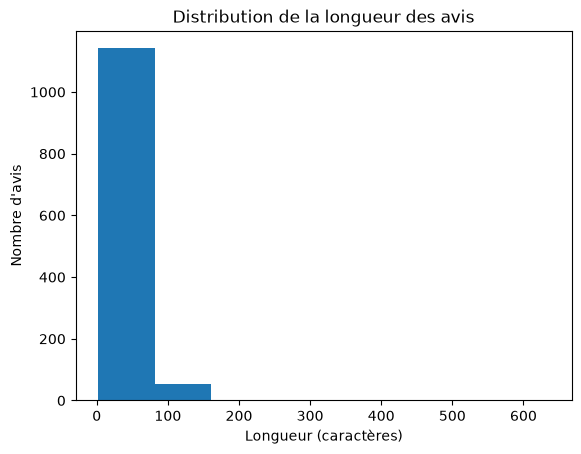

In [15]:
plt.hist(non_vide['longueur'], bins=8)
plt.xlabel('Longueur (caractères)')
plt.ylabel("Nombre d'avis")
plt.title('Distribution de la longueur des avis')
plt.show()

a) Existe-t-il des textes anormalement longs ?

In [16]:
q3 = non_vide['longueur'].quantile(0.75)
iqr = q3 - non_vide['longueur'].quantile(0.25)
seuil_haut = q3 + 1.5 * iqr
print('seuil :', seuil_haut)
print('nb textes anormalement longs :', (non_vide['longueur'] > seuil_haut).sum())

seuil : 84.5
nb textes anormalement longs : 41


b) Existe-t-il beaucoup de textes très courts ?

In [17]:
print('nb textes < 10 caractères :', (non_vide['longueur'] < 10).sum())
print(non_vide[non_vide['longueur'] < 10]['texte'].tolist())

nb textes < 10 caractères : 4
['OK', 'Pas bon', 'OK', '   ']


9) Détecter les textes vides

In [18]:
vides = df[df['texte'].isna() | (df['texte'].str.strip() == '')]
print(len(vides))

6


10) Détecter les doublons sur le texte

In [19]:
print(df.duplicated(subset='texte').sum())

881


11) Les classes sont-elles équilibrées ?

In [20]:
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

sentiment
positif    64.7
neutre     20.5
negatif    14.8
Name: proportion, dtype: float64


Non, les classes sont déséquilibrées.

12) Quelle est la classe majoritaire ?

In [21]:
print(df['sentiment'].value_counts().idxmax())

positif


13) Quelles métriques de classification à envisager d’utiliser ?

Avec un tel déséquilibre, l'accuracy seule serait trompeuse (prédire toujours "positif" donnerait déjà ~65% de bonnes réponses)
. Il vaut mieux utiliser le F1-score macro, la matrice de confusion, et le F1 par classe (pour surveiller la classe minoritaire "negatif").

14) Détecter les caractères particuliers : emojis ; URLs ; hashtags ; mentions ; chiffres ; caractères
spéciaux ; ponctuation répétée ; …

In [22]:
n = len(df)
has_url = df['texte'].str.contains(r'http\S+', na=False).sum()
has_mention = df['texte'].str.contains(r'@\w+', na=False).sum()
has_hashtag = df['texte'].str.contains(r'#\w+', na=False).sum()
has_digits = df['texte'].str.contains(r'\d', na=False).sum()
has_rep_punct = df['texte'].str.contains(r'([!?.])\1{1,}', na=False, regex=True).sum()

print('URLs :', has_url)
print('Mentions :', has_mention)
print('Hashtags :', has_hashtag)
print('Chiffres :', has_digits)
print('Ponctuation répétée :', has_rep_punct)

URLs : 143
Mentions : 128
Hashtags : 127
Chiffres : 142
Ponctuation répétée : 141


C:\Users\DELL\AppData\Local\Temp\ipykernel_6272\3955467779.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_rep_punct = df['texte'].str.contains(r'([!?.])\1{1,}', na=False, regex=True).sum()
